In [1]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexUpset)

OUTDIR <- "../../outputs/Extended/"
dir.create(OUTDIR, recursive = TRUE, showWarnings = FALSE)

## accepts either a .rds or a .csv, since the two cohorts are stored differently
load_df <- function(stem) {
  hits <- list.files(dirname(stem),
                     pattern = paste0("^", basename(stem), "\\.(rds|RDS|csv)$"),
                     full.names = TRUE)
  if (!length(hits)) stop("no file matching ", stem, ".{rds,csv}")
  if (grepl("csv$", hits[1], ignore.case = TRUE))
    readr::read_csv(hits[1], show_col_types = FALSE) else readRDS(hits[1])
}

lucas_df <- load_df("../../data/lucas_df")
mica_df  <- load_df("../../data/mica_df")

## Shared UpSet layout. `set_fill` colours the marginal bars, `bar_fill` the
## intersection-ratio bars. Membership columns must be logical for ComplexUpset.
upset_panel <- function(mat, sets, set_fill, bar_fill) {
  upset(
    mat,
    intersect = sets,
    set_sizes = upset_set_size(
      geom = geom_bar(fill = set_fill, colour = "black", width = 0.4),
      position = "left"
    ) +
      labs(y = "Number of Patients") +
      theme(axis.title.x = element_text(size = 16),
            axis.text.x  = element_text(size = 12)),
    base_annotations = list(
      "Intersection ratio" = intersection_ratio(
        text_mapping = aes(label = !!upset_text_percentage()),
        counts  = FALSE,
        mapping = aes(fill = "bars_color"),
        text    = list(size = 16)
      ) +
        scale_fill_manual(values = c(bars_color = bar_fill), guide = "none") +
        theme(axis.title.y = element_text(size = 18),
              axis.text.y  = element_text(size = 12))
    )
  ) + theme(axis.text.y = element_text(size = 18))
}

## keep the seven most frequent symptoms, in descending frequency
top_n_sets <- function(mat, n = 7) names(sort(colSums(mat), decreasing = TRUE))[1:n]


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




LUCAS patients with a referral reason: 205 


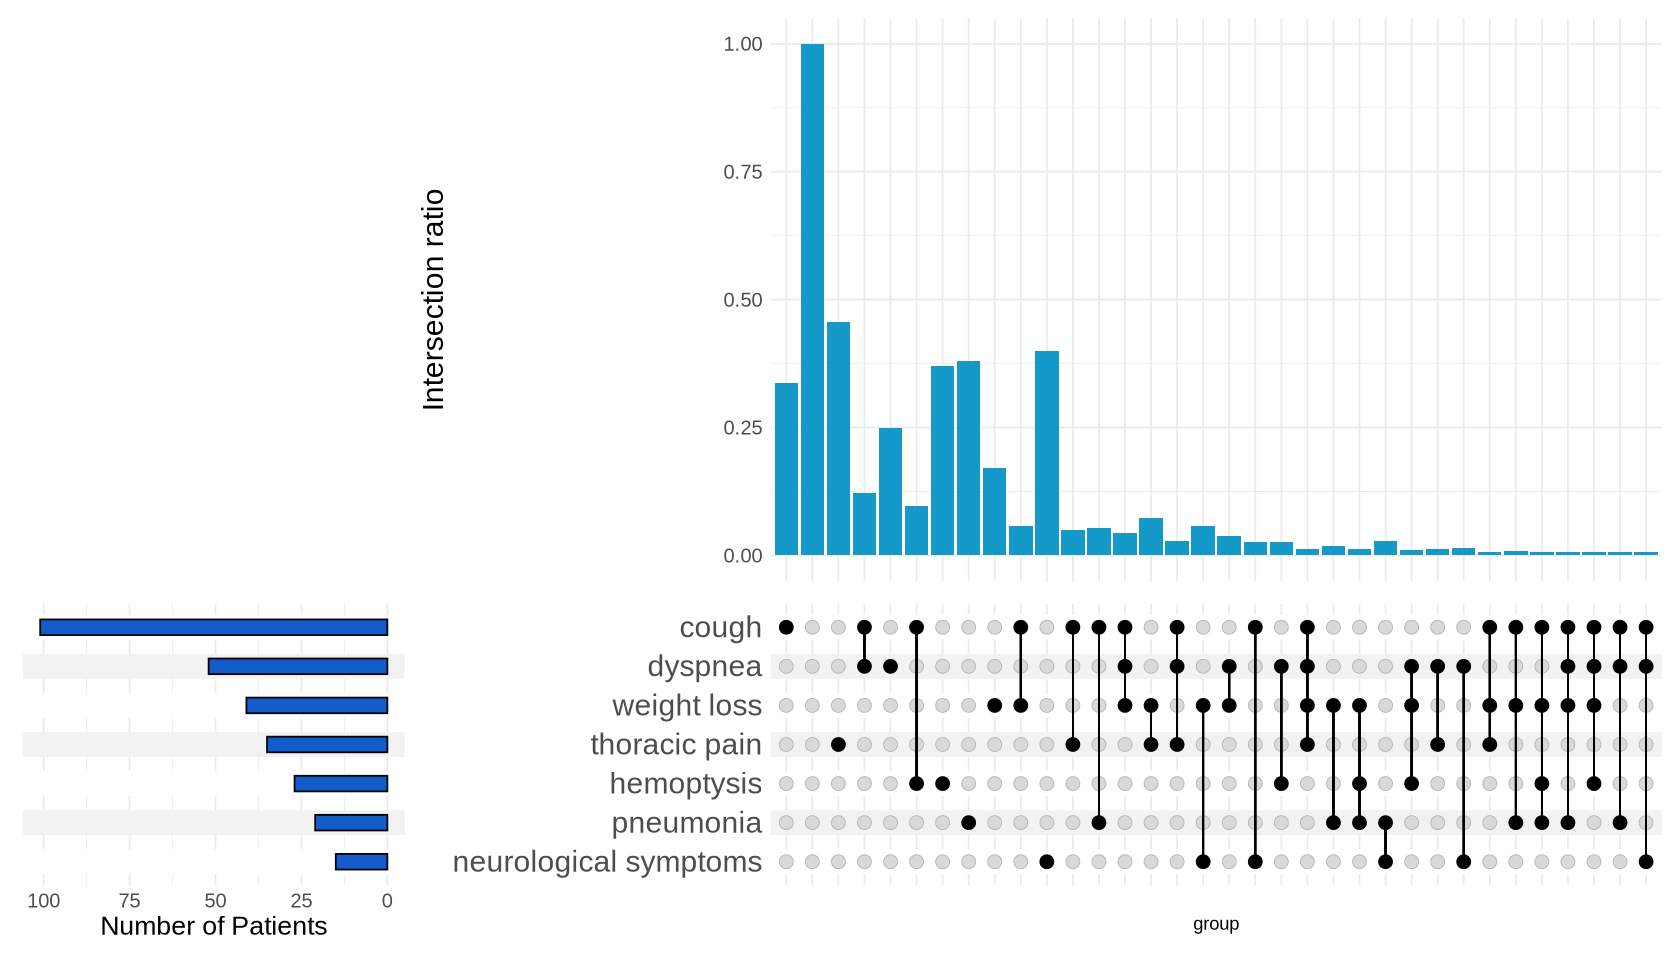

In [2]:
## `Reason for referral` is free text, comma-separated: explode to one row per
## patient-symptom pair, then pivot to a membership matrix. Patients with a
## missing referral reason drop out, so the ratio denominator is the referred
## subset, not the full cohort.
lucas_mat <- lucas_df %>%
  transmute(id = row_number(),
            reason = strsplit(as.character(`Reason for referral`), ",\\s*")) %>%
  unnest(reason) %>%
  mutate(reason = trimws(reason)) %>%
  filter(!is.na(reason), reason != "") %>%
  mutate(value = TRUE) %>%
  pivot_wider(id_cols = id, names_from = reason,
              values_from = value, values_fill = FALSE) %>%
  select(-id)

cat("LUCAS patients with a referral reason:", nrow(lucas_mat), "\n")

lucas_sets <- top_n_sets(lucas_mat)
p_lucas <- upset_panel(lucas_mat[, lucas_sets], lucas_sets,
                       set_fill = "#145CC9", bar_fill = "#1499C9")

options(repr.plot.width = 14, repr.plot.height = 8)
p_lucas
ggsave(file.path(OUTDIR, "Supple-Fig-1a-LUCAS.png"),
       p_lucas, width = 14, height = 8, dpi = 600)

In [3]:
mica_df <- mica_df %>%
  filter(type == "healthy" | (type == "cancer" & `Coded Type` == "Lung (LU)"))


MICA patients: 400 
   Weight loss        Fatigue Abdominal pain   Low appetite    Night sweat 
           210            146             97             52             51 
          Pain      Back pain        Malaise          Fever            DVT 
            37             26             23             23              2 


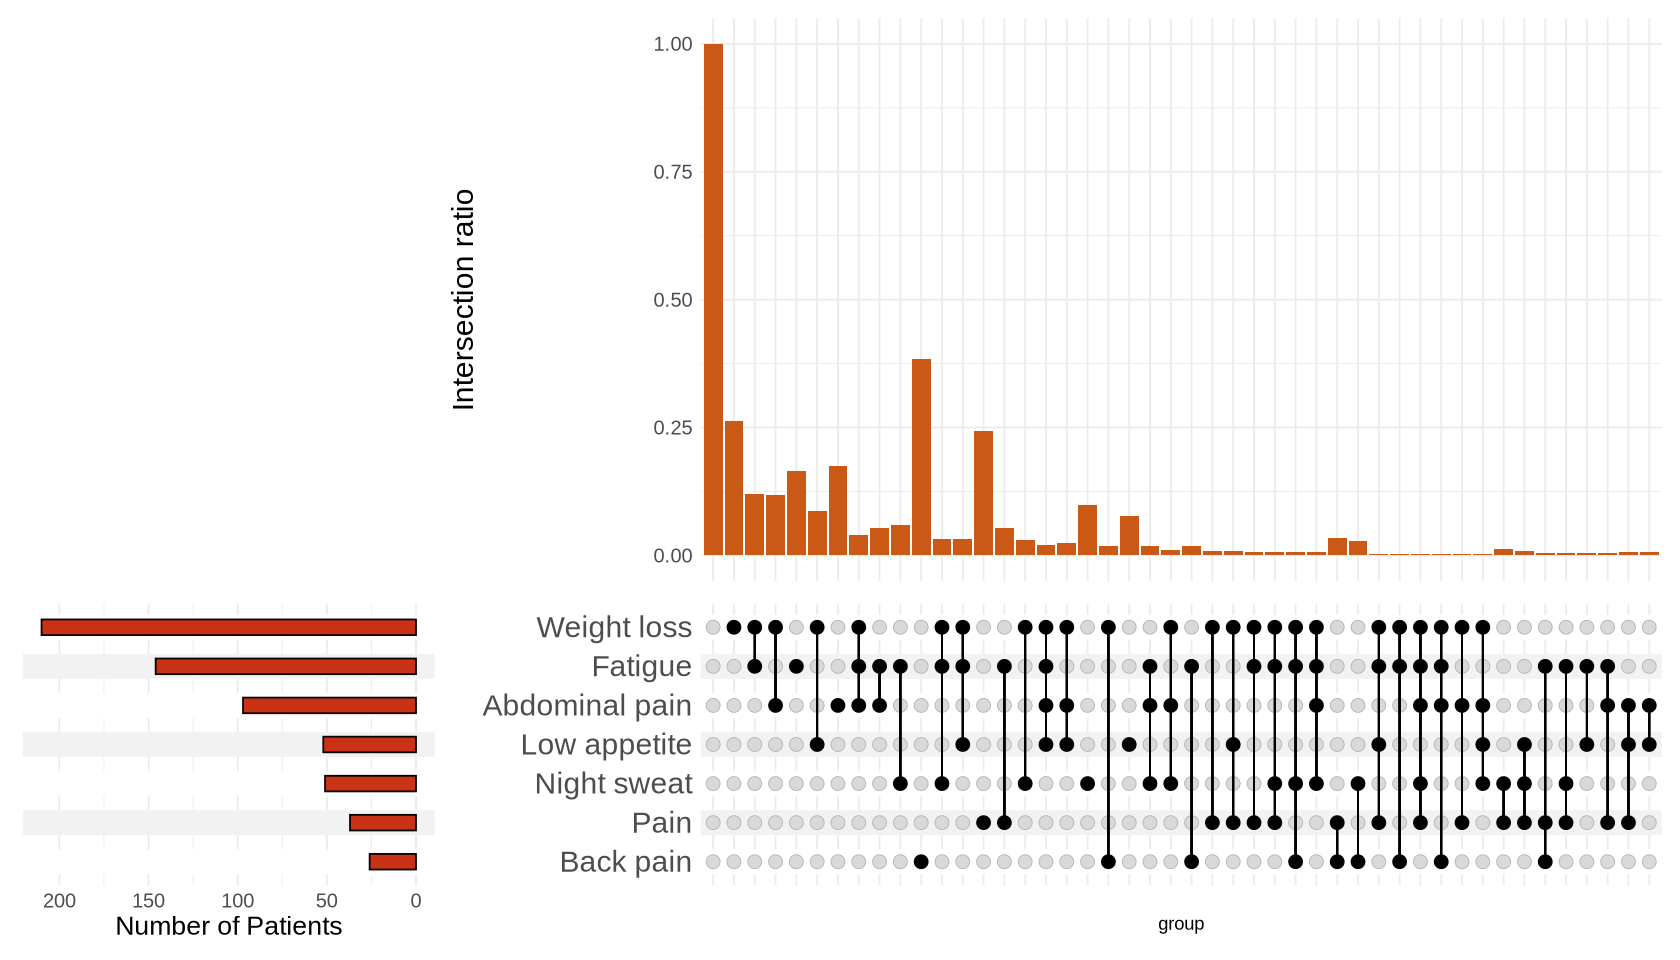

In [6]:

mica_recode <- c(
  "Mallaise"      = "Malaise",
  "Fatigue"       = "Fatigue",
  "Weight loss"   = "Weight loss",
  "Low appetite"  = "Low appetite",
  "Fever"         = "Fever",
  "Abdominalia"   = "Abdominal pain",
  "Pain"          = "Pain",
  "Back pain"     = "Back pain",
  "Neight sweat"  = "Night sweat",
  "DVT"           = "DVT"
)

present <- intersect(names(mica_recode), colnames(mica_df))
if (length(present) < length(mica_recode))
  warning("not found: ", paste(setdiff(names(mica_recode), present), collapse = ", "))

## Columns are numeric 0/1 with some NA. Treating NA as "symptom not recorded"
## matches the colSums(na.rm = TRUE) used to rank the sets.
mica_mat <- mica_df[, present] %>%
  mutate(across(everything(), ~ !is.na(.x) & .x > 0)) %>%
  setNames(unname(mica_recode[present]))

cat("MICA patients:", nrow(mica_mat), "\n")
print(sort(colSums(mica_mat), decreasing = TRUE))

mica_sets <- top_n_sets(mica_mat)
p_mica <- upset_panel(mica_mat[, mica_sets], mica_sets,
                      set_fill = "#C93214", bar_fill = "#C95914")

options(repr.plot.width = 14, repr.plot.height = 8)
p_mica


In [7]:
ggsave(file.path(OUTDIR, "Supple-Fig-1b-MICA.png"),
       p_mica, width = 14, height = 8, dpi = 600)

In [ ]:
# Done #